## Objective
The objective of this project is to build an XGBoost Regressor for predicting medical insurance charges using customer characteristics such as age, sex, BMI, number of children, smoking status, and region. The dataset will be examined, cleaned, and explored before developing baseline and tuned regression models. Model performance will be evaluated using MSE, MAE, RMSE, MAPE, and R² score to understand the prediction results from different perspectives. An appropriate scoring metric will be selected for hyperparameter tuning based on the problem statement, prediction objective, and characteristics of the target variable. Training and testing performance will also be compared to identify possible overfitting. The final model will be selected based on its overall predictive performance and its ability to generalise well to unseen data.

## **Task 1**
- *Import the libraries required for data preparation, modelling, evaluation, and visualisation*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from xgboost import XGBRegressor

# Data Preparation

## **Task 2**

- *Load the dataset and display the first few records*
- *Check the dataset shape, data types, and column names*
- *Check for missing values and duplicate records*
- *Remove duplicate records from the dataset*

In [2]:
df = pd.read_csv('insurance.csv'); df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print('Dataset shape:', df.shape)
print('\nColumn names:'); print(df.columns.tolist())
print('\nDataset information:'); df.info()

Dataset shape: (1338, 7)

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
print('Missing values in each column:'); print(df.isnull().sum())
print('\nDuplicate records:', df.duplicated().sum())

Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate records: 1


In [5]:
df = df.drop_duplicates().reset_index(drop = True); print('Cleaned dataset shape:', df.shape)

Cleaned dataset shape: (1337, 7)


## **Task 3**
- *Compare the average insurance charges for smokers and non-smokers using a bar chart*

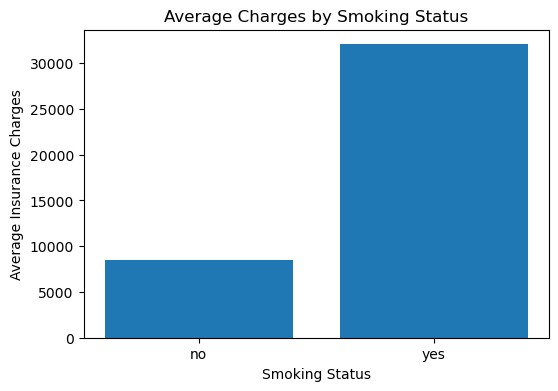

In [6]:
average_charges = df.groupby('smoker')['charges'].mean()
plt.figure(figsize = (6, 4))
plt.bar(average_charges.index, average_charges.values)
plt.xlabel('Smoking Status'); plt.ylabel('Average Insurance Charges')
plt.title('Average Charges by Smoking Status')
plt.show()

## **Task 4**
- *Separate the predictor variables and the target variable*

In [7]:
X = df.drop('charges', axis = 1); y = df['charges']
print('Feature dataset shape:', X.shape); print('Target dataset shape:', y.shape)

Feature dataset shape: (1337, 6)
Target dataset shape: (1337,)


## **Task 5**
- *Split the feature and target datasets into training and testing sets*

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
print('Training feature shape:', X_train.shape); print('Testing feature shape:', X_test.shape)

Training feature shape: (1069, 6)
Testing feature shape: (268, 6)


## **Task 6**
- *Encode the categorical features by fitting the encoder on the training data and applying the same transformation to the testing data*

In [9]:
categorical_columns = X_train.select_dtypes(include = 'object').columns.tolist()
print('Categorical columns:'); print(categorical_columns)

Categorical columns:
['sex', 'smoker', 'region']


In [10]:
encoder = OneHotEncoder(handle_unknown = 'ignore', drop = 'first', sparse_output = False)
preprocessor = ColumnTransformer(transformers = [('encoder', encoder, categorical_columns)], 
                                 remainder = 'passthrough', verbose_feature_names_out = False)

In [11]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
X_train_encoded = pd.DataFrame(X_train_encoded, columns = feature_names, index = X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns = feature_names, index = X_test.index)

print('Encoded training shape:', X_train_encoded.shape); print('Encoded testing shape:', X_test_encoded.shape)

Encoded training shape: (1069, 8)
Encoded testing shape: (268, 8)


# Model Training

## **Task 7**
- *Build and train a baseline XGBoost Regressor using the training data*
- *Display the parameters used by the baseline XGBoost model*

In [12]:
b_model = XGBRegressor(random_state=42); b_model.fit(X_train_encoded, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [13]:
print(b_model.get_params())

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


## **Task 8**
- *Generate predictions for the training and testing datasets using the baseline model*

In [14]:
b_train_pred = b_model.predict(X_train_encoded)
b_test_pred = b_model.predict(X_test_encoded)

print('Training predictions:', b_train_pred[:5]); print('Testing predictions:', b_test_pred[:5])

Training predictions: [ 2838.4133  4749.6367 31702.248  13426.68   10087.914 ]
Testing predictions: [ 9064.293   5771.2485 11402.364  40061.19    4426.116 ]


## **Task 9**
- *Plot the actual and predicted medical insurance charges for the training and testing datasets using the baseline XGBoost model*

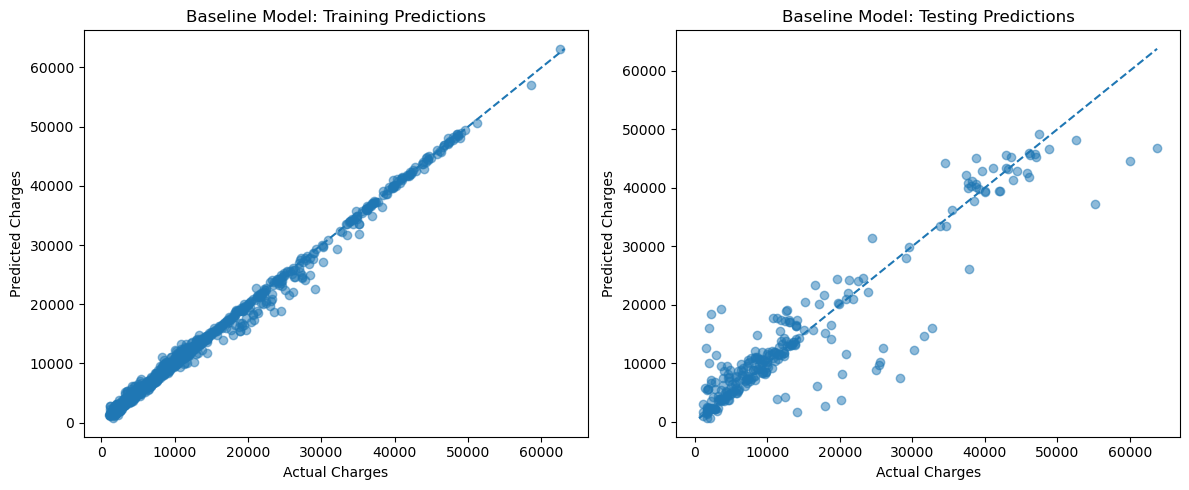

In [15]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
axes[0].scatter(y_train, b_train_pred, alpha = 0.5)
train_minimum = min(y_train.min(), b_train_pred.min())
train_maximum = max(y_train.max(), b_train_pred.max())
axes[0].plot([train_minimum, train_maximum], [train_minimum, train_maximum], linestyle = '--')
axes[0].set_xlabel('Actual Charges'); axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Baseline Model: Training Predictions')
axes[1].scatter(y_test, b_test_pred, alpha = 0.5)
test_minimum = min(y_test.min(), b_test_pred.min())
test_maximum = max(y_test.max(), b_test_pred.max())
axes[1].plot([test_minimum, test_maximum], [test_minimum, test_maximum], linestyle = '--')
axes[1].set_xlabel('Actual Charges'); axes[1].set_ylabel('Predicted Charges')
axes[1].set_title('Baseline Model: Testing Predictions')
plt.tight_layout()
plt.show()

## **Task 10**
- *Create a line graph to compare the first 50 actual and predicted testing values using the baseline XGBoost model*

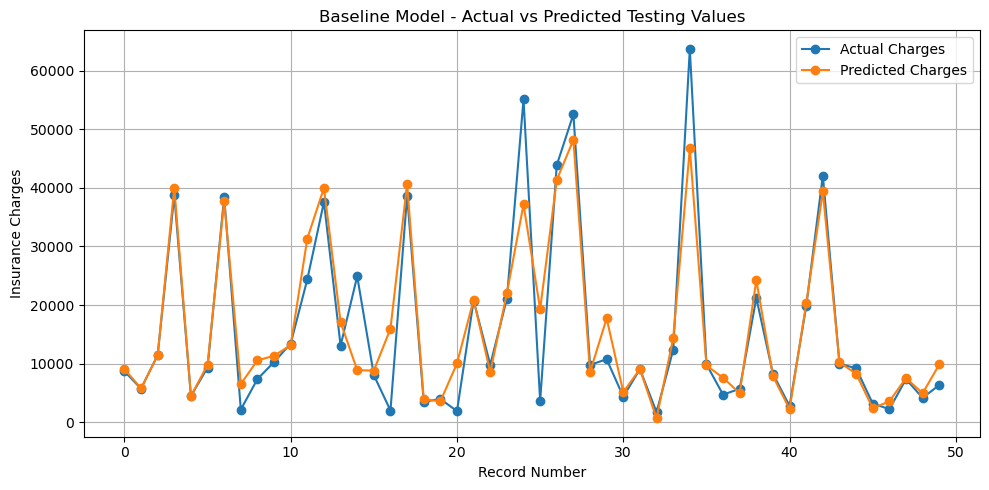

In [16]:
test_actual = y_test.reset_index(drop = True)[:50]
baseline_test_predicted = b_test_pred[:50]
plt.figure(figsize = (10, 5))
plt.plot(test_actual, marker = 'o', label = 'Actual Charges')
plt.plot(baseline_test_predicted, marker = 'o', label = 'Predicted Charges')
plt.xlabel('Record Number'); plt.ylabel('Insurance Charges')
plt.title('Baseline Model - Actual vs Predicted Testing Values')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Model Interpretation

## **Task 11**
- *Evaluate the baseline model using MSE, MAE, RMSE, MAPE, and R² score for the training and testing datasets*
- *Select an appropriate evaluation metric and calculate the gap between the training and testing scores to check for overfitting*

In [17]:
b_train_mse = mean_squared_error(y_train, b_train_pred)
b_test_mse = mean_squared_error(y_test, b_test_pred)
b_train_mae = mean_absolute_error(y_train, b_train_pred)
b_test_mae = mean_absolute_error(y_test, b_test_pred)
b_train_rmse = np.sqrt(b_train_mse)
b_test_rmse = np.sqrt(b_test_mse)
b_train_mape = mean_absolute_percentage_error(y_train, b_train_pred) * 100
b_test_mape = mean_absolute_percentage_error(y_test, b_test_pred) * 100
b_train_r2 = r2_score(y_train, b_train_pred)
b_test_r2 = r2_score(y_test, b_test_pred)

print('Baseline Training MSE:', round(b_train_mse, 2))
print('Baseline Testing MSE:', round(b_test_mse, 2))
print('\nBaseline Training MAE:', round(b_train_mae, 2))
print('Baseline Testing MAE:', round(b_test_mae, 2))
print('\nBaseline Training RMSE:', round(b_train_rmse, 2))
print('Baseline Testing RMSE:', round(b_test_rmse, 2))
print('\nBaseline Training MAPE:', round(b_train_mape, 2), '%')
print('Baseline Testing MAPE:', round(b_test_mape, 2), '%')
print('\nBaseline Training R² Score:', round(b_train_r2, 3))
print('Baseline Testing R² Score:', round(b_test_r2, 3))

Baseline Training MSE: 684938.3
Baseline Testing MSE: 25132255.03

Baseline Training MAE: 480.59
Baseline Testing MAE: 2869.65

Baseline Training RMSE: 827.61
Baseline Testing RMSE: 5013.21

Baseline Training MAPE: 6.86 %
Baseline Testing MAPE: 39.48 %

Baseline Training R² Score: 0.995
Baseline Testing R² Score: 0.863


In [18]:
b_rmse_gap = abs(b_test_rmse - b_train_rmse); print('Baseline RMSE Gap:', round(b_rmse_gap, 2))

Baseline RMSE Gap: 4185.6


## **Task 12**
- *Identify and visualise the five most influential features used by the baseline model*

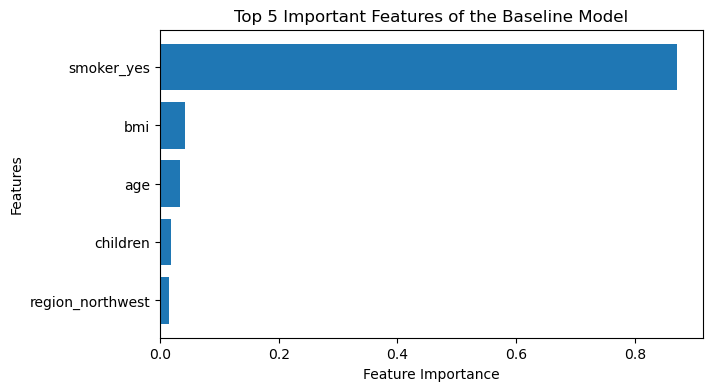

In [19]:
b_feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': b_model.feature_importances_})
b_top_features = b_feature_importance.sort_values(by = 'Importance', ascending = False).head(5)
plt.figure(figsize = (7, 4))
plt.barh(b_top_features['Feature'][::-1], b_top_features['Importance'][::-1])
plt.xlabel('Feature Importance'); plt.ylabel('Features')
plt.title('Top 5 Important Features of the Baseline Model')
plt.show()

# Hyperparameter Tuning

## **Task 13**
- *Tune the XGBoost Regressor using `n_estimators`, `learning_rate`, and `max_depth` with five-fold cross-validation and an appropriate scoring metric*
- *Display the best hyperparameters and the best cross-validation score*
- *Select and train the best estimator as the tuned model*

In [20]:
parameter_grid = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, 4]}

In [21]:
tuning_model = XGBRegressor(objective = 'reg:squarederror', random_state = 42, n_jobs = 1)
grid_search = GridSearchCV(estimator = tuning_model, param_grid = parameter_grid, 
                           scoring = 'neg_root_mean_squared_error', cv = 5, n_jobs = 1, verbose = 10)
grid_search.fit(X_train_encoded, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5; 1/12] START learning_rate=0.05, max_depth=2, n_estimators=100..........
[CV 1/5; 1/12] END learning_rate=0.05, max_depth=2, n_estimators=100;, score=-5479.852 total time=   0.0s
[CV 2/5; 1/12] START learning_rate=0.05, max_depth=2, n_estimators=100..........
[CV 2/5; 1/12] END learning_rate=0.05, max_depth=2, n_estimators=100;, score=-4231.076 total time=   0.0s
[CV 3/5; 1/12] START learning_rate=0.05, max_depth=2, n_estimators=100..........
[CV 3/5; 1/12] END learning_rate=0.05, max_depth=2, n_estimators=100;, score=-4427.819 total time=   0.0s
[CV 4/5; 1/12] START learning_rate=0.05, max_depth=2, n_estimators=100..........
[CV 4/5; 1/12] END learning_rate=0.05, max_depth=2, n_estimators=100;, score=-4276.469 total time=   0.0s
[CV 5/5; 1/12] START learning_rate=0.05, max_depth=2, n_estimators=100..........
[CV 5/5; 1/12] END learning_rate=0.05, max_depth=2, n_estimators=100;, score=-4677.732 total time=   0.0s
[CV 

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [22]:
print('Best Hyperparameters:'); print(grid_search.best_params_)
print('\nBest Cross-Validation RMSE:'); print(round(-grid_search.best_score_, 2))

Best Hyperparameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Best Cross-Validation RMSE:
4586.73


In [23]:
f_model = grid_search.best_estimator_
f_model.fit(X_train_encoded, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## **Task 14**
- *Generate predictions for the training and testing datasets using the tuned XGBoost model*

In [24]:
f_train_pred = f_model.predict(X_train_encoded)
f_test_pred = f_model.predict(X_test_encoded)

print('Tuned training predictions:', f_train_pred[:5])
print('Tuned testing predictions:', f_test_pred[:5])

Tuned training predictions: [ 4543.9985  6215.598  14198.422  14966.189  11221.11  ]
Tuned testing predictions: [10695.874   8142.0796 12421.216  38922.08    7077.225 ]


## **Task 15**
- *Plot the actual and predicted medical insurance charges for the training and testing datasets using the tuned XGBoost model*

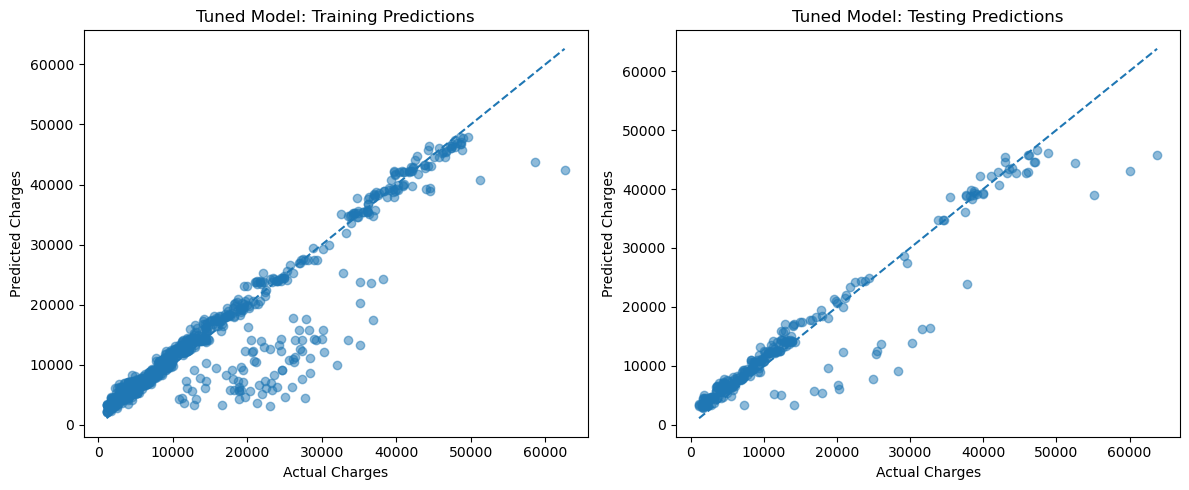

In [25]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
axes[0].scatter(y_train, f_train_pred, alpha = 0.5)
train_minimum = min(y_train.min(), f_train_pred.min())
train_maximum = max(y_train.max(), f_train_pred.max())
axes[0].plot([train_minimum, train_maximum], [train_minimum, train_maximum], linestyle = '--')
axes[0].set_xlabel('Actual Charges'); axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Tuned Model: Training Predictions')
axes[1].scatter(y_test, f_test_pred, alpha = 0.5)
test_minimum = min(y_test.min(), f_test_pred.min())
test_maximum = max(y_test.max(), f_test_pred.max())
axes[1].plot([test_minimum, test_maximum], [test_minimum, test_maximum], linestyle = '--')
axes[1].set_xlabel('Actual Charges'); axes[1].set_ylabel('Predicted Charges')
axes[1].set_title('Tuned Model: Testing Predictions')
plt.tight_layout()
plt.show()

## **Task 16**
- *Create a line graph to compare the first 50 actual and predicted testing values using the tuned XGBoost model*

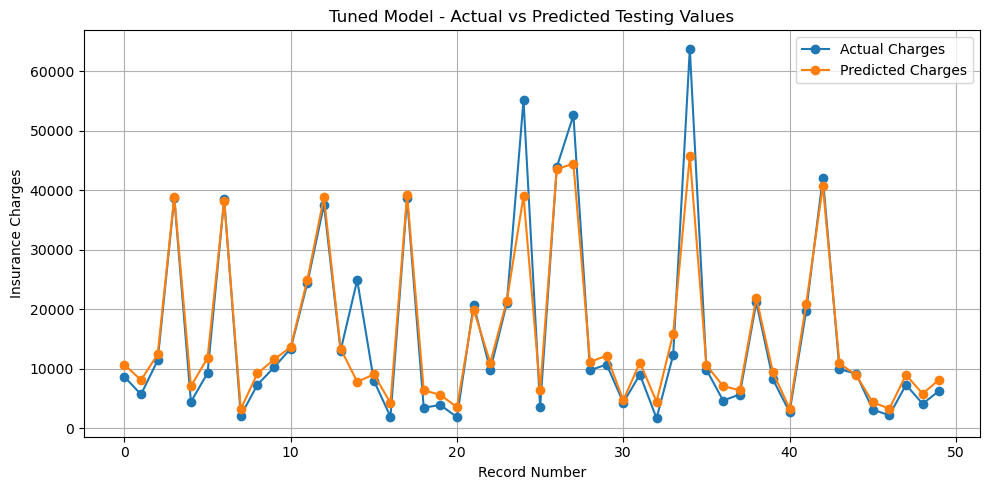

In [26]:
test_actual = y_test.reset_index(drop = True)[:50]
tuned_test_predicted = f_test_pred[:50]
plt.figure(figsize = (10, 5))
plt.plot(test_actual, marker = 'o', label = 'Actual Charges')
plt.plot(tuned_test_predicted, marker = 'o', label = 'Predicted Charges')
plt.xlabel('Record Number'); plt.ylabel('Insurance Charges')
plt.title('Tuned Model - Actual vs Predicted Testing Values')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## **Task 17**
- *Evaluate the tuned model using MSE, MAE, RMSE, MAPE, and R² score for the training and testing datasets*
- *Select an appropriate evaluation metric and calculate the gap between the training and testing scores of the tuned model to check for overfitting*

In [27]:
f_train_mse = mean_squared_error(y_train, f_train_pred)
f_test_mse = mean_squared_error(y_test, f_test_pred)
f_train_mae = mean_absolute_error(y_train, f_train_pred)
f_test_mae = mean_absolute_error(y_test, f_test_pred)
f_train_rmse = np.sqrt(f_train_mse)
f_test_rmse = np.sqrt(f_test_mse)
f_train_mape = mean_absolute_percentage_error(y_train, f_train_pred) * 100
f_test_mape = mean_absolute_percentage_error(y_test, f_test_pred) * 100
f_train_r2 = r2_score(y_train, f_train_pred)
f_test_r2 = r2_score(y_test, f_test_pred)

print('Tuned Training MSE:', round(f_train_mse, 2))
print('Tuned Testing MSE:', round(f_test_mse, 2))
print('\nTuned Training MAE:', round(f_train_mae, 2))
print('Tuned Testing MAE:', round(f_test_mae, 2))
print('\nTuned Training RMSE:', round(f_train_rmse, 2))
print('Tuned Testing RMSE:', round(f_test_rmse, 2))
print('\nTuned Training MAPE:', round(f_train_mape, 2), '%')
print('Tuned Testing MAPE:', round(f_test_mape, 2), '%')
print('\nTuned Training R² Score:', round(f_train_r2, 3))
print('Tuned Testing R² Score:', round(f_test_r2, 3))

Tuned Training MSE: 17808197.91
Tuned Testing MSE: 17940162.08

Tuned Training MAE: 2336.85
Tuned Testing MAE: 2469.44

Tuned Training RMSE: 4219.98
Tuned Testing RMSE: 4235.58

Tuned Training MAPE: 30.06 %
Tuned Testing MAPE: 32.54 %

Tuned Training R² Score: 0.87
Tuned Testing R² Score: 0.902


In [28]:
f_rmse_gap = abs(f_test_rmse - f_train_rmse); print('Tuned RMSE Gap:', round(f_rmse_gap, 2))

Tuned RMSE Gap: 15.61


# Model Comparison

## **Task 18**
- *Compare the training and testing performance of the baseline and tuned XGBoost models using all regression metrics*
- *Create a DataFrame to compare the performance gaps of the baseline and tuned models using the selected evaluation metric*

In [29]:
comparison = pd.DataFrame({
    'Model': ['Baseline', 'Baseline', 'Tuned', 'Tuned'],
    'Dataset': ['Training', 'Testing', 'Training', 'Testing'],
    'MSE': [b_train_mse, b_test_mse, f_train_mse, f_test_mse],
    'MAE': [b_train_mae, b_test_mae, f_train_mae, f_test_mae],
    'RMSE': [b_train_rmse, b_test_rmse, f_train_rmse, f_test_rmse],
    'MAPE (%)': [b_train_mape, b_test_mape, f_train_mape, f_test_mape],
    'R² Score': [b_train_r2, b_test_r2, f_train_r2, f_test_r2]
})

comparison.round(3)

,Model,Dataset,MSE,MAE,RMSE,MAPE (%),R² Score
0,Baseline,Training,6.849383e+05,480.591,827.610,6.860,0.995
1,Baseline,Testing,2.513226e+07,2869.653,5013.208,39.481,0.863
2,Tuned,Training,1.780820e+07,2336.848,4219.976,30.061,0.870
3,Tuned,Testing,1.794016e+07,2469.437,4235.583,32.535,0.902


In [30]:
gap_comparison = pd.DataFrame({'Model': ['Baseline Model', 'Tuned Model'], 'RMSE Gap': [b_rmse_gap, f_rmse_gap]})
gap_comparison.round(2)

,Model,RMSE Gap
0,Baseline Model,4185.60
1,Tuned Model,15.61
